In [1]:
import pandas as pd
import os
import random
from sklearn.model_selection import train_test_split
import re
import sys
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, confusion_matrix
import torch.nn.functional as F

In [2]:
# ------------------------------------------
# Base folder names
# ------------------------------------------
train_folder = "train_res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0"
test_folder  = "test_res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0"

# Choose how many tickers to use
# Set to None if you want all tickers
MAX_TICKERS = None

# Make ticker selection reproducible
TICKER_SEED = 42

# Build paths
train_csv_path = os.path.join(train_folder, "labels.csv")
test_csv_path  = os.path.join(test_folder, "labels.csv")

# Load csv files
train_full_df = pd.read_csv(train_csv_path)
test_full_df  = pd.read_csv(test_csv_path)

# Force labels to be integers
train_full_df["label"] = train_full_df["label"].astype(int)
test_full_df["label"]  = test_full_df["label"].astype(int)

# Convert dates
for df_ in [train_full_df, test_full_df]:
    df_["start_date"] = pd.to_datetime(df_["start_date"])
    df_["end_date"]   = pd.to_datetime(df_["end_date"])
    df_["date"]       = df_["end_date"]   # use end_date as observation date

# --------------------------------------------------
# LIMIT NUMBER OF TICKERS
# Pick tickers from the train set, then keep only
# those same tickers in both train and test
# --------------------------------------------------
all_train_tickers = sorted(train_full_df["ticker"].unique())
print(f"Total tickers available in train before filtering: {len(all_train_tickers)}")

if MAX_TICKERS is not None:
    if MAX_TICKERS > len(all_train_tickers):
        raise ValueError(
            f"MAX_TICKERS={MAX_TICKERS} is larger than the number of available train tickers ({len(all_train_tickers)})."
        )

    rng = random.Random(TICKER_SEED)
    selected_tickers = sorted(rng.sample(all_train_tickers, MAX_TICKERS))

    train_full_df = train_full_df[train_full_df["ticker"].isin(selected_tickers)].copy()
    test_full_df  = test_full_df[test_full_df["ticker"].isin(selected_tickers)].copy()

    print(f"Using {len(selected_tickers)} tickers: {selected_tickers[:10]}{' ...' if len(selected_tickers) > 10 else ''}")

print(f"\nRows after ticker filtering:")
print(f"Train rows: {len(train_full_df)}")
print(f"Test rows:  {len(test_full_df)}")

print(f"\nUnique tickers after filtering:")
print(f"Train tickers: {train_full_df['ticker'].nunique()}")
print(f"Test tickers:  {test_full_df['ticker'].nunique()}")

print("\nTrain head:")
print(train_full_df.head())

print("\nTrain info:")
print(train_full_df.info())

print("\nTrain label counts:")
print(train_full_df["label"].value_counts())

print("\nTest label counts:")
print(test_full_df["label"].value_counts())

Total tickers available in train before filtering: 1104

Rows after ticker filtering:
Train rows: 971736
Test rows:  71262

Unique tickers after filtering:
Train tickers: 1104
Test tickers:  701

Train head:
                                          image_path  ticker start_date  \
0  train_res_96_color_candlestick_vol_1_ma_1_bb_0...   10078 1993-01-29   
1  train_res_96_color_candlestick_vol_1_ma_1_bb_0...   10078 1993-02-01   
2  train_res_96_color_candlestick_vol_1_ma_1_bb_0...   10078 1993-02-02   
3  train_res_96_color_candlestick_vol_1_ma_1_bb_0...   10078 1993-02-03   
4  train_res_96_color_candlestick_vol_1_ma_1_bb_0...   10078 1993-02-04   

    end_date  close_now  close_future  label       date  
0 1993-02-04     36.750        35.000      0 1993-02-04  
1 1993-02-05     35.000        35.125      1 1993-02-05  
2 1993-02-08     35.875        33.500      0 1993-02-08  
3 1993-02-09     35.625        33.250      0 1993-02-09  
4 1993-02-10     35.625        33.875      0 1993-0

Tjekker at Billederne eksistere og fjerner rækker hvor billeder ikke eksisterer

Sorterer data efter tid, så rækker der tilhører samme Ticker/firma ikke længere kommer efter hinanden. Det er fordi man i Finans verden gerne vil bruge gammel data til at forudsige ny data. Altså skal rækker med samme Ticker/firma ikke ligge sammen. Derimod skal den træne gammel data fra alle de forskellige Firmaer.

Step 5: Split by unique dates, not by rows

This is important. Since many companies share the same dates, it is better to split by the set of unique dates.

In [5]:
# --------------------------------------------------
# Split only the TRAIN folder into train/validation
# Keep TEST folder as final out-of-sample test set
# --------------------------------------------------

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.30,              # Jiang uses 70/30 train/val
    random_state=42,
    stratify=train_full_df["label"]
)

# The separate test folder is already the test set
test_df = test_full_df.copy()

# Optional: reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

print("\nLabel balance:")
print(f"Train up: {train_df['label'].mean():.2%}")
print(f"Val up:   {val_df['label'].mean():.2%}")
print(f"Test up:  {test_df['label'].mean():.2%}")

Train shape: (680215, 8)
Val shape:   (291521, 8)
Test shape:  (71262, 8)

Date ranges:
Train: 1993-01-29 00:00:00 to 2000-12-21 00:00:00
Val:   1993-01-29 00:00:00 to 2000-12-21 00:00:00
Test:  2001-02-01 00:00:00 to 2003-12-23 00:00:00

Label balance:
Train up: 51.00%
Val up:   51.00%
Test up:  51.38%


In [6]:
print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

print("\nNumber of tickers:")
print("Train:", train_df["ticker"].nunique())
print("Val:  ", val_df["ticker"].nunique())
print("Test: ", test_df["ticker"].nunique())


Date ranges:
Train: 1993-01-29 00:00:00 to 2000-12-21 00:00:00
Val:   1993-01-29 00:00:00 to 2000-12-21 00:00:00
Test:  2001-02-01 00:00:00 to 2003-12-23 00:00:00

Number of tickers:
Train: 1104
Val:   1094
Test:  701


In [7]:
train_label_balance = train_df["label"].mean()
val_label_balance   = val_df["label"].mean()
test_label_balance  = test_df["label"].mean()

print("\nLabel balance:")
print(f"Train up: {train_label_balance:.1%}")
print(f"Val up:   {val_label_balance:.1%}")
print(f"Test up:  {test_label_balance:.1%}")


Label balance:
Train up: 51.0%
Val up:   51.0%
Test up:  51.4%


In [6]:
print(sys.executable)

c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe


In [8]:
folder_name = os.path.basename(train_folder)

match = re.match(r"(?:train_|test_)?res_(\d+)_(color|grayscale)", folder_name)
if not match:
    raise ValueError(f"Could not read resolution/color mode from folder name: {folder_name}")

IMG_RESOLUTION = int(match.group(1))
COLOR_MODE = match.group(2)

PIL_MODE = "RGB" if COLOR_MODE == "color" else "L"
INPUT_CHANNELS = 3 if COLOR_MODE == "color" else 1

print("IMG_RESOLUTION:", IMG_RESOLUTION)
print("COLOR_MODE:", COLOR_MODE)
print("PIL_MODE:", PIL_MODE)
print("INPUT_CHANNELS:", INPUT_CHANNELS)

IMG_RESOLUTION: 96
COLOR_MODE: color
PIL_MODE: RGB
INPUT_CHANNELS: 3


Image batch shape: torch.Size([128, 3, 32, 15])
Label batch shape: torch.Size([128])
First 10 labels: tensor([0, 0, 1, 1, 1, 0, 1, 1, 0, 1])


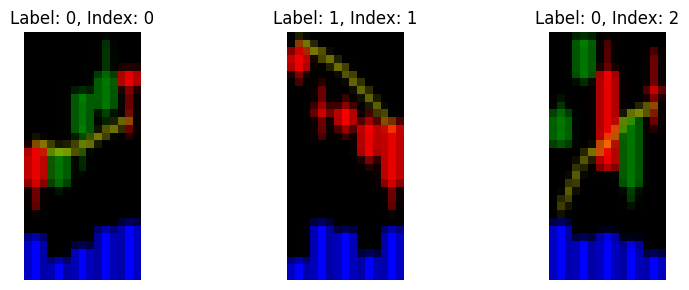

In [9]:
class StockImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert(PIL_MODE)
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label, idx


# Do NOT resize
basic_transform = transforms.Compose([
    transforms.Resize((32, 15)),
    transforms.ToTensor()
])

train_dataset = StockImageDataset(train_df, transform=basic_transform)
val_dataset   = StockImageDataset(val_df, transform=basic_transform)
test_dataset  = StockImageDataset(test_df, transform=basic_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    pin_memory=True
)

# Test one batch
images, labels, idx = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

# Plot 3 resulting images
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for i in range(3):
    image, label, idx = train_dataset[i]
    img_np = image.numpy()

    if img_np.shape[0] == 1:
        axes[i].imshow(img_np[0], cmap="gray")
    else:
        axes[i].imshow(np.transpose(img_np, (1, 2, 0)))

    axes[i].set_title(f"Label: {label}, Index: {idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

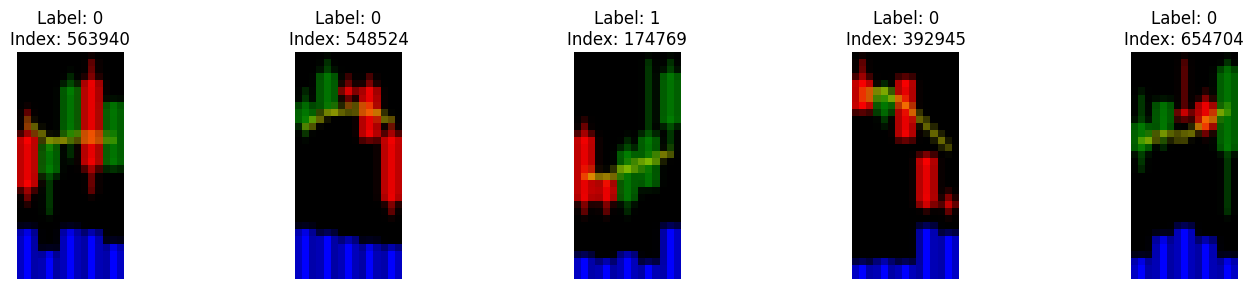

In [9]:
random_indices = random.sample(range(len(train_dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, idx in zip(axes, random_indices):
    image, label, dataset_idx = train_dataset[idx]
    img_np = image.numpy()

    if img_np.shape[0] == 1:
        ax.imshow(img_np[0], cmap="gray")
    else:
        ax.imshow(np.transpose(img_np, (1, 2, 0)))

    ax.set_title(f"Label: {label}\nIndex: {dataset_idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Hvis PyTorch bruger CPU i stedet for Nvidia GPU er det fordi du har installeret en CPU version af PyTorch. Så kan man køre følgende kommandoer for at få CUDA version med PyTorch
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [10]:
print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Python: c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
Torch CUDA version: 12.6
GPU count: 1
GPU name: NVIDIA GeForce RTX 4070


In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        # Using padding='same' (requires recent PyTorch versions) to preserve spatial dimensions.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=(5, 3), padding='same')
        self.bn1 = nn.BatchNorm2d(64)
        self.act1 = nn.LeakyReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 1))

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(5, 3), padding='same')
        self.bn2 = nn.BatchNorm2d(128)
        self.act2 = nn.LeakyReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 1))

        self.dropout = nn.Dropout(p=0.5)
        # After two pooling layers:
        #   Input: 32x15
        #   After conv1 (same padding): 32x15, then pool1 (2x1): 16x15.
        #   After conv2 (same padding): 16x15, then pool2 (2x1): 8x15.
        # Flattened features: 128 * 8 * 15 = 15360.
        self.fc = nn.Linear(128 * 8 * 15, num_classes) # Jonas sendte dette men virker kun for 32x15
        # self.fc = nn.Linear(128 * 24 * 96, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.dropout(x)
        x = self.fc(x)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels, _) in enumerate(loader, 1):
        if batch_idx % PRINT_EVERY == 0 or batch_idx == 1 or batch_idx == len(loader):
            print(f"    Batch {batch_idx}/{len(loader)}")
            
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

criterion = nn.CrossEntropyLoss()



In [ ]:
PRINT_EVERY = 500

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SimpleCNN(
    #input_channels=INPUT_CHANNELS,
    #input_size=IMG_RESOLUTION,
    num_classes=2
).to(device)

print("Trainable params:", count_parameters(model))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

num_epochs = 50
patience = 2   # Jiang-style early stopping after 2 non-improving epochs
best_val_loss = float("inf")
patience_counter = 0

model_save_path = os.path.join(
    train_folder,
    f"best_jiang_baseline_i5_{COLOR_MODE}_{IMG_RESOLUTION}.pth"
)

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print("  Saved best model.")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("  Early stopping triggered.")
            break

print("Best model path:", model_save_path)

Using device: cuda
Trainable params: 157058
    Batch 1/5315
    Batch 500/5315
    Batch 1000/5315
    Batch 1500/5315
    Batch 2000/5315
    Batch 2500/5315
    Batch 3000/5315
    Batch 3500/5315
    Batch 4000/5315
    Batch 4500/5315
    Batch 5000/5315
    Batch 5315/5315
Epoch 1/50
  Train loss: 0.7281 | Train acc: 0.5070
  Val   loss: 0.6924 | Val   acc: 0.5218
  Saved best model.
    Batch 1/5315
    Batch 500/5315
    Batch 1000/5315
    Batch 1500/5315
    Batch 2000/5315
    Batch 2500/5315
    Batch 3000/5315
    Batch 3500/5315
    Batch 4000/5315
    Batch 4500/5315
    Batch 5000/5315
    Batch 5315/5315
Epoch 2/50
  Train loss: 0.7043 | Train acc: 0.5115
  Val   loss: 0.6920 | Val   acc: 0.5251
  Saved best model.
    Batch 1/5315
    Batch 500/5315
    Batch 1000/5315
    Batch 1500/5315
    Batch 2000/5315
    Batch 2500/5315
    Batch 3000/5315
    Batch 3500/5315
    Batch 4000/5315
    Batch 4500/5315
    Batch 5000/5315
    Batch 5315/5315
Epoch 3/50
  Train los

In [15]:
# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(
    #input_channels=INPUT_CHANNELS,
    #input_size=IMG_RESOLUTION,
    num_classes=2
).to(device)

model_save_path = os.path.join(
    train_folder,
    f"best_jiang_baseline_i5_{COLOR_MODE}_{IMG_RESOLUTION}.pth"
)
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc:  {test_acc:.4f}")

model.eval()

# Reset index so dataset idx matches dataframe row
test_df = test_df.reset_index(drop=True)

# Create empty column for predicted probability of "up"
test_df["pred_prob_up"] = None

with torch.no_grad():
    for images, labels, indices in test_loader:
        images = images.to(device)

        outputs = model(images)

        # Option A: convert 2 logits to probabilities
        probs_up = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()

        for i, idx in enumerate(indices.numpy()):
            test_df.loc[idx, "pred_prob_up"] = float(probs_up[i])

# Optional: also create predicted class from 0.5 threshold
test_df["pred_label"] = (test_df["pred_prob_up"].astype(float) >= 0.5).astype(int)

# Save file
predictions_path = os.path.join(test_folder, "test_predictions.csv")
test_df.to_csv(predictions_path, index=False)

print("Saved predictions to:", predictions_path)

Test loss: 0.6910
Test acc:  0.5245
Saved predictions to: test_res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0\test_predictions.csv


In [39]:
# ==========================================
# 1) True labels and model predictions
# ==========================================
test_true_labels = test_df["label"].to_numpy(dtype=int)
test_predicted_prob_up = test_df["pred_prob_up"].astype(float).to_numpy()
test_predicted_labels = (test_predicted_prob_up >= 0.5).astype(int)

# ==========================================
# 2) True class balances from each split
# ==========================================
train_true_up_rate = train_df["label"].mean()
val_true_up_rate = val_df["label"].mean()
test_true_up_rate = test_df["label"].mean()

# Combined train+val balance = development-set class prior
development_true_up_rate = (
    train_df["label"].sum() + val_df["label"].sum()
) / (len(train_df) + len(val_df))

# ==========================================
# 3) Model prediction distribution
# ==========================================
test_predicted_up_rate = test_predicted_labels.mean()

test_predicted_prob_up_min = test_predicted_prob_up.min()
test_predicted_prob_up_max = test_predicted_prob_up.max()
test_predicted_prob_up_mean = test_predicted_prob_up.mean()
test_predicted_prob_up_std = test_predicted_prob_up.std()

test_share_prob_below_50 = np.mean(test_predicted_prob_up < 0.5)
test_share_prob_at_or_above_50 = np.mean(test_predicted_prob_up >= 0.5)

print("=== True label balance ===")
print(f"Train up-rate                    = {train_true_up_rate:.1%}")
print(f"Val up-rate                      = {val_true_up_rate:.1%}")
print(f"Development up-rate (train+val)  = {development_true_up_rate:.1%}")
print(f"Test up-rate                     = {test_true_up_rate:.1%}")

print("\n=== Model prediction distribution on test set ===")
print(f"Predicted up-rate                = {test_predicted_up_rate:.1%}")
print(f"Min predicted prob(up)           = {test_predicted_prob_up_min:.4f}")
print(f"Max predicted prob(up)           = {test_predicted_prob_up_max:.4f}")
print(f"Mean predicted prob(up)          = {test_predicted_prob_up_mean:.2%}   bør være så tæt på Test up-rate som muligt")
print(f"Std of predicted prob(up)        = {test_predicted_prob_up_std:.4f}")
print(f"Share with prob(up) < 0.50       = {test_share_prob_below_50:.1%}")
print(f"Share with prob(up) >= 0.50      = {test_share_prob_at_or_above_50:.1%}")

# ==========================================
# 4) Classification metrics
# ==========================================
test_accuracy = accuracy_score(test_true_labels, test_predicted_labels)
test_balanced_accuracy = balanced_accuracy_score(test_true_labels, test_predicted_labels)
test_auc = roc_auc_score(test_true_labels, test_predicted_prob_up)
test_log_loss = log_loss(test_true_labels, test_predicted_prob_up)

print("\n=== Test classification metrics ===")
print(f"Test accuracy                    = {test_accuracy:.4f}")
print(f"Test balanced accuracy           = {test_balanced_accuracy:.4f}")
print(f"Test AUC                         = {test_auc:.4f}")
print(f"Test log loss                    = {test_log_loss:.4f}")

# ==========================================
# 5) Confusion matrix
# ==========================================
conf_matrix = confusion_matrix(test_true_labels, test_predicted_labels, labels=[0, 1])
true_negatives, false_positives, false_negatives, true_positives = conf_matrix.ravel()

test_recall_down = true_negatives / (true_negatives + false_positives) if (true_negatives + false_positives) > 0 else np.nan
test_recall_up = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else np.nan

print("\n=== Confusion matrix ===")
print(conf_matrix)
print(f"TN (true down predicted down)    = {true_negatives}")
print(f"FP (true down predicted up)      = {false_positives}")
print(f"FN (true up predicted down)      = {false_negatives}")
print(f"TP (true up predicted up)        = {true_positives}")
print(f"Recall for Down class            = {test_recall_down:.4f}")
print(f"Recall for Up class              = {test_recall_up:.4f}")


=== True label balance ===
Train up-rate                    = 54.4%
Val up-rate                      = 54.4%
Development up-rate (train+val)  = 54.4%
Test up-rate                     = 54.4%

=== Model prediction distribution on test set ===
Predicted up-rate                = 66.8%
Min predicted prob(up)           = 0.1511
Max predicted prob(up)           = 0.8034
Mean predicted prob(up)          = 53.43%   bør være så tæt på Test up-rate som muligt
Std of predicted prob(up)        = 0.0845
Share with prob(up) < 0.50       = 33.2%
Share with prob(up) >= 0.50      = 66.8%

=== Test classification metrics ===
Test accuracy                    = 0.5760
Test balanced accuracy           = 0.5618
Test AUC                         = 0.5898
Test log loss                    = 0.6768

=== Confusion matrix ===
[[2677 4032]
 [2201 5791]]
TN (true down predicted down)    = 2677
FP (true down predicted up)      = 4032
FN (true up predicted down)      = 2201
TP (true up predicted up)        = 5791
Reca

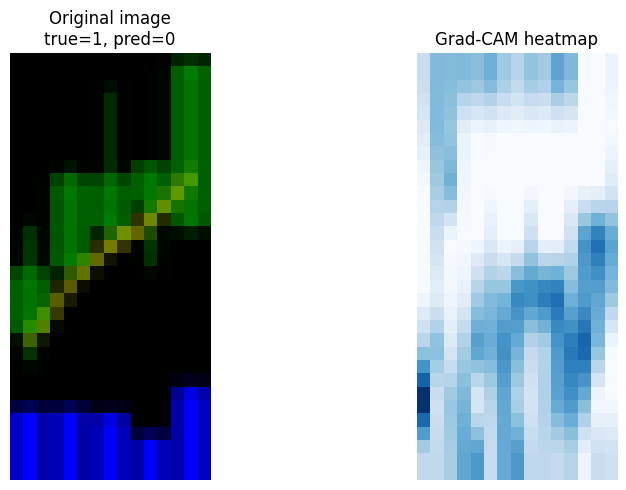

Random test index: 23638
True label:        1
Predicted label:   0
Prob down:         0.5624
Prob up:           0.4376


In [211]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_handle = target_layer.register_forward_hook(self.save_activation)
        self.bwd_handle = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[0, class_idx]

        self.model.zero_grad()
        score.backward()

        activations = self.activations[0]
        gradients = self.gradients[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], device=activations.device)
        for c, w in enumerate(weights):
            cam += w * activations[c]

        cam = F.relu(cam)

        if cam.max() > 0:
            cam = cam / cam.max()

        cam = cam.unsqueeze(0).unsqueeze(0)
        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        return cam.squeeze().cpu().numpy(), output.detach()

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()


# choose layer
target_layer = model.pool2
gradcam = GradCAM(model, target_layer)

# random image
idx = random.randint(0, len(test_dataset) - 1)
image, label, row_idx = test_dataset[idx]
input_tensor = image.unsqueeze(0).to(device)

# grad-cam
cam, logits = gradcam.generate(input_tensor)
probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
pred = int(np.argmax(probs))

# prepare image
img = image.detach().cpu().numpy()

if img.shape[0] == 1:
    img = img[0]
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
else:
    img = np.transpose(img, (1, 2, 0))
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()

# plot original and heatmap separately
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# original image
if img.ndim == 2:
    axes[0].imshow(img, cmap="gray")
else:
    axes[0].imshow(img)
axes[0].set_title(f"Original image\ntrue={label}, pred={pred}")
axes[0].axis("off")

# heatmap only
axes[1].imshow(cam, cmap="Blues")
axes[1].set_title("Grad-CAM heatmap")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Random test index: {idx}")
print(f"True label:        {label}")
print(f"Predicted label:   {pred}")
print(f"Prob down:         {probs[0]:.4f}")
print(f"Prob up:           {probs[1]:.4f}")

gradcam.remove_hooks()